In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data 
df = pd.read_csv('raw_analyst_ratings.csv')

# 2. Clean Dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# 3. Create Features
df['headline_len'] = df['headline'].apply(len)

# 4. Show Initial Stats for Sunday's report
print(f"Total Headlines: {df.shape[0]}")
df.head()

Total Headlines: 55987


,Unnamed: 0,headline,url,publisher,date,stock,headline_len
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


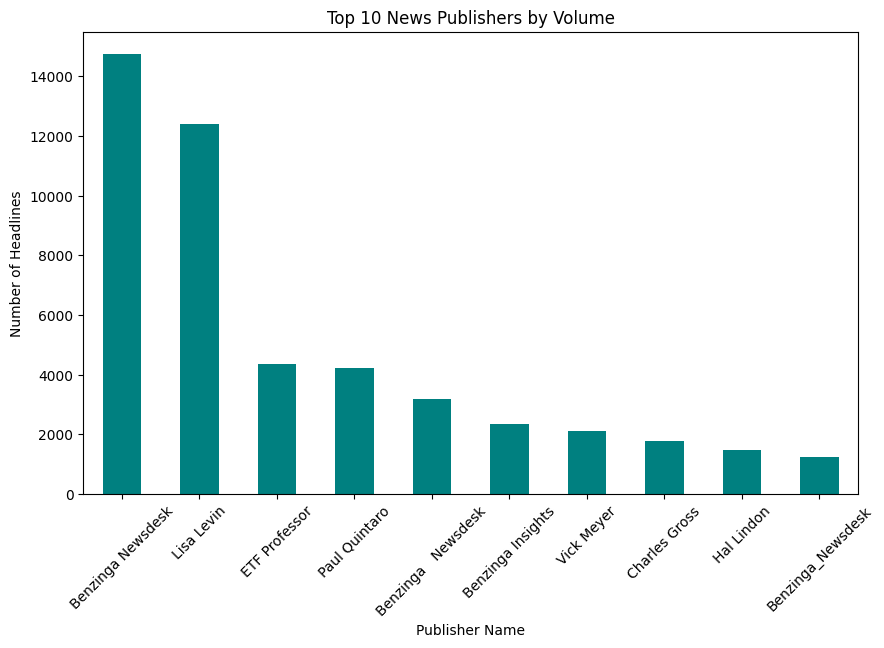

In [6]:
# Counting headlines per publisher
top_publishers = df['publisher'].value_counts().head(10)

# Plotting the results
plt.figure(figsize=(10, 6))
top_publishers.plot(kind='bar', color='teal')
plt.title('Top 10 News Publishers by Volume')
plt.xlabel('Publisher Name')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)
plt.show()

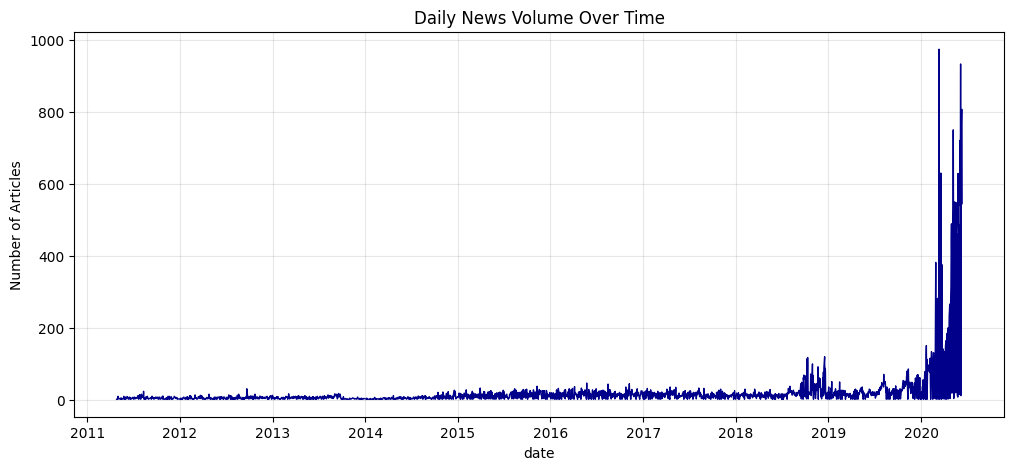

In [7]:
# Grouping by date to see daily volume
daily_news = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(12, 5))
daily_news.plot(color='darkblue', linewidth=1)
plt.title('Daily News Volume Over Time')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

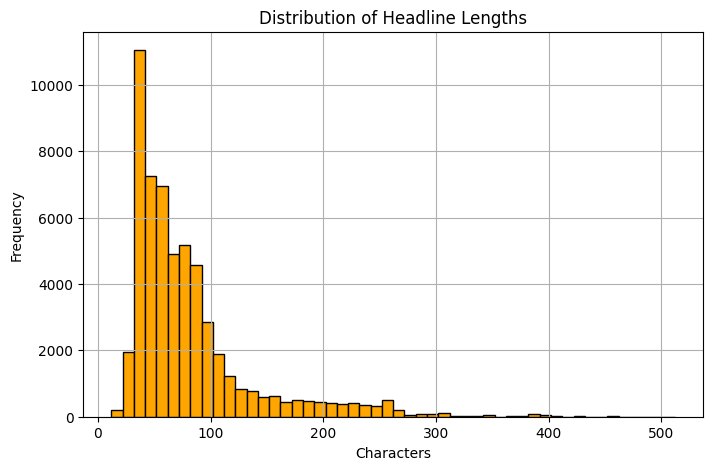

In [8]:
# Plotting the length of headlines
plt.figure(figsize=(8, 5))
df['headline_len'].hist(bins=50, color='orange', edgecolor='black')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()